Visualize multidimensional data set using at least three direct visualization methods. Matlab (Statistical Toolbox), Orange, Visulab, Xmdv, Pandas, or other software may be used. Include at least three images in the report and comment them. Include general conclusions describing insights about the data and comparing results of different methods indicating which one is most useful for the analyzed data.

In [1]:
!pip install ucimlrepo

In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
mushroom = fetch_ucirepo(id=73) 
  
# data (as pandas dataframes) 
X = mushroom.data.features 
y = mushroom.data.targets 
  
# metadata 
print(mushroom.metadata) 
  
# variable information 
print(mushroom.variables)

{'uci_id': 73, 'name': 'Mushroom', 'repository_url': 'https://archive.ics.uci.edu/dataset/73/mushroom', 'data_url': 'https://archive.ics.uci.edu/static/public/73/data.csv', 'abstract': 'From Audobon Society Field Guide; mushrooms described in terms of physical characteristics; classification: poisonous or edible', 'area': 'Biology', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 8124, 'num_features': 22, 'feature_types': ['Categorical'], 'demographics': [], 'target_col': ['poisonous'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1981, 'last_updated': 'Thu Aug 10 2023', 'dataset_doi': '10.24432/C5959T', 'creators': [], 'intro_paper': None, 'additional_info': {'summary': "This data set includes descriptions of hypothetical samples corresponding to 23 species of gilled mushrooms in the Agaricus and Lepiota Family (pp. 500-525).  Each species is identified as definitely edible, definitely po

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# Combine features and target
df = X.copy()
df['class'] = y.iloc[:, 0]   # target column

# Encode categorical data
encoder = LabelEncoder()
df_encoded = df.apply(encoder.fit_transform)

# For readability, map class back to labels
df_encoded['class'] = df_encoded['class'].map({0: 'edible', 1: 'poisonous'})

In [7]:
cols = ['class', 'odor', 'gill-color', 'cap-shape', 'spore-print-color']
subset = df_encoded[cols]

In [12]:
import matplotlib as mpl

mpl.rcParams.update({
    'font.size': 18,
    'axes.titlesize': 24,
    'axes.labelsize': 22,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 20,
    'lines.linewidth': 2.5
})

In [13]:
CLASS_COLORS = {
    'edible': '#1f77b4',      # strong blue
    'poisonous': '#d62728'    # strong red
}

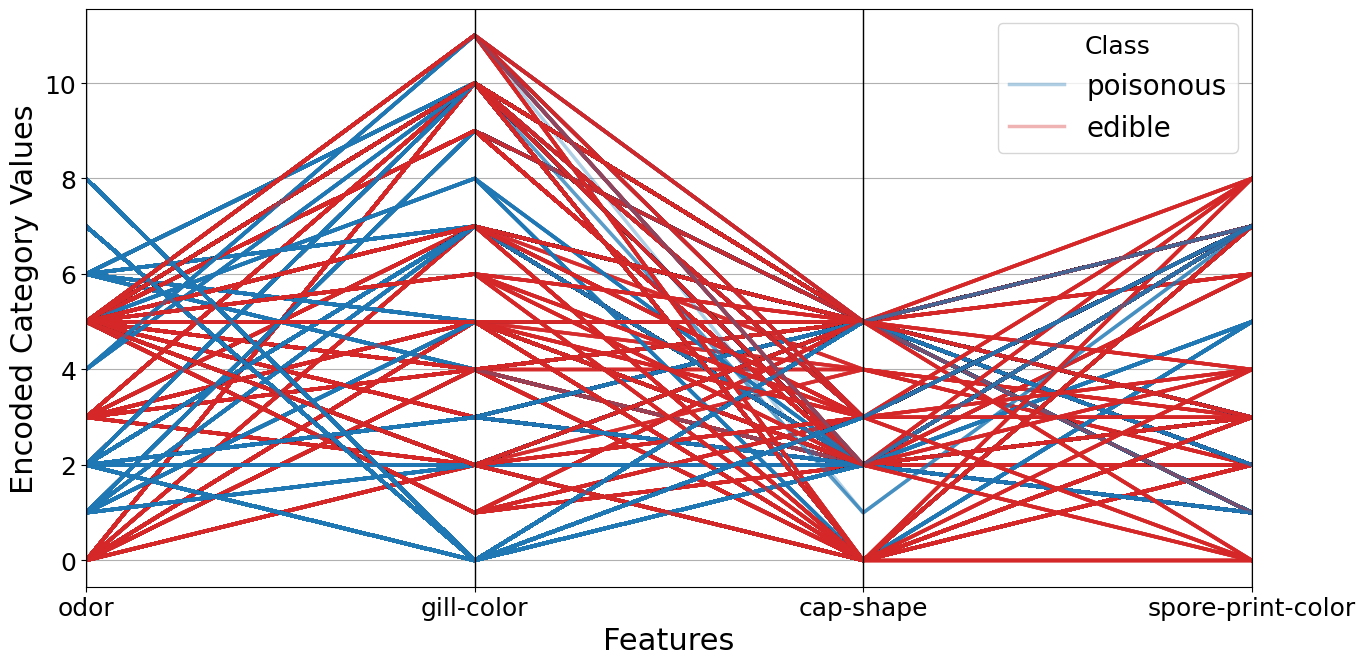

In [17]:
from pandas.plotting import parallel_coordinates
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

parallel_coordinates(
  subset,
  'class',
  color=[CLASS_COLORS['edible'], CLASS_COLORS['poisonous']],
  alpha=0.35
)

plt.xlabel("Features")
plt.ylabel("Encoded Category Values")
plt.legend(title="Class", loc='upper right')
plt.tight_layout()
plt.show()

In [21]:
# Combine features and target (if not already done)
df = X.copy()
df['class'] = y.iloc[:, 0]

# Odor values per class
edible_odors = sorted(df[df['class'] == 'e']['odor'].unique())
poisonous_odors = sorted(df[df['class'] == 'p']['odor'].unique())

print("Odor labels for EDIBLE mushrooms:")
for o in edible_odors:
    print(f"  - {o}")

print("\nOdor labels for POISONOUS mushrooms:")
for o in poisonous_odors:
    print(f"  - {o}")

Odor labels for EDIBLE mushrooms:
  - a
  - l
  - n

Odor labels for POISONOUS mushrooms:
  - c
  - f
  - m
  - n
  - p
  - s
  - y


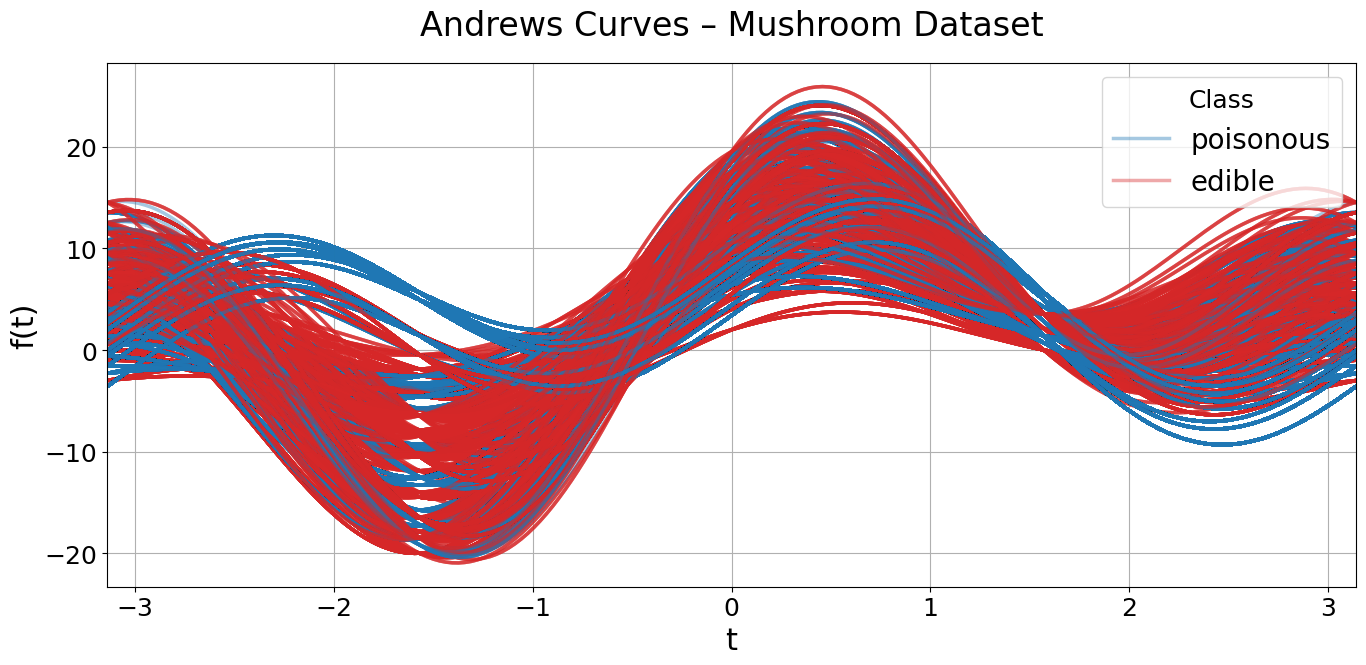

In [ ]:
from pandas.plotting import andrews_curves

plt.figure(figsize=(14, 7))

andrews_curves(
    subset,
    'class',
    color=[CLASS_COLORS['edible'], CLASS_COLORS['poisonous']],
    alpha=0.4
)

plt.xlabel("t")
plt.ylabel("f(t)")
plt.legend(title="Class", loc='upper right')
plt.tight_layout()
plt.show()

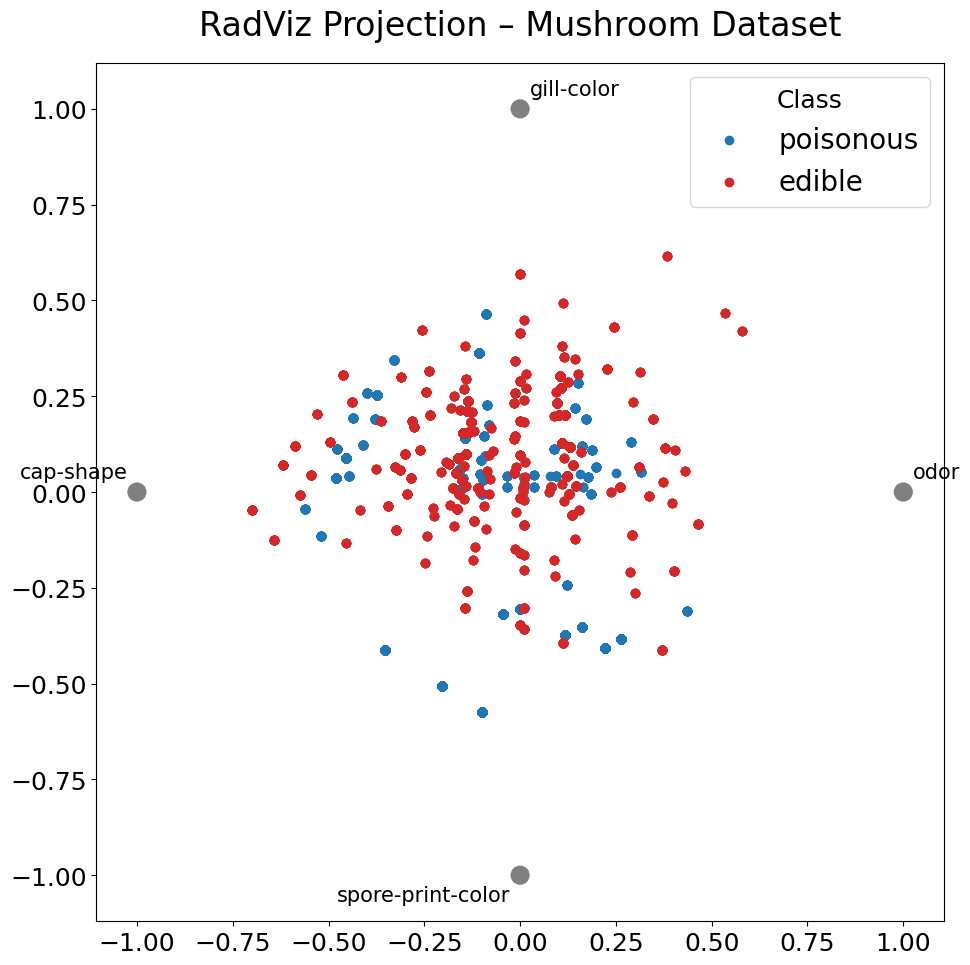

In [16]:
from pandas.plotting import radviz

plt.figure(figsize=(10, 10))

radviz(
    subset,
    'class',
    color=[CLASS_COLORS['edible'], CLASS_COLORS['poisonous']]
)

plt.title("RadViz Projection – Mushroom Dataset", pad=20)
plt.legend(title="Class", loc='best')
plt.tight_layout()
plt.show()